In [2]:
import pandas as pd
df = pd.read_csv('dataset/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


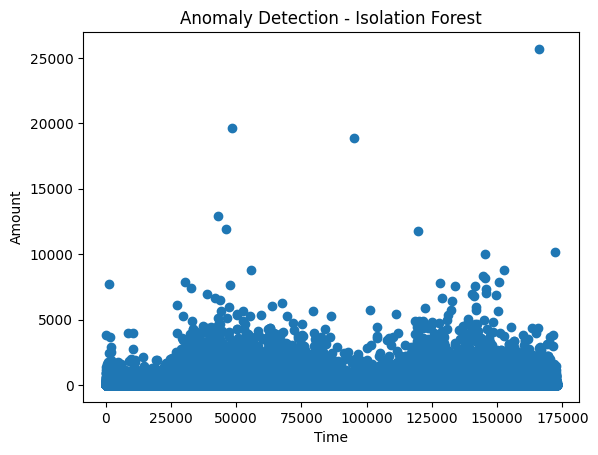

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df['Time'], df['Amount'])
plt.xlabel('Time')
plt.ylabel('Amount')
plt.title('Anomaly Detection - Isolation Forest')
plt.show()

In [5]:
from sklearn.ensemble import IsolationForest

In [15]:
clf = IsolationForest(contamination=0.001)
clf.fit(df[['Time', 'Amount']])
predictions = clf.predict(df[['Time', 'Amount']])

In [16]:
predictions

array([1, 1, 1, ..., 1, 1, 1])

In [17]:
import numpy as np
index = np.where(predictions <0)
index

(array([   164,   1281,   1388,   1632,   2178,   2453,   2622,   2677,
          4727,   5058,   5704,   6783,   6971,   7243,   7469,   7485,
          7600,   7617,   8398,   8472,   9601,  11218,  11222,  15364,
         15714,  15835,  17454,  18280,  18428,  18552,  18570,  18653,
         19386,  19760,  19920,  20946,  21586,  22112,  22439,  22636,
         23088,  23128,  23852,  23931,  24616,  24633,  25612,  25614,
         25682,  26432,  29279,  29293,  29667,  29808,  30589,  30950,
         31252,  31686,  32145,  32359,  32905,  32932,  33756,  33949,
         34493,  36029,  36154,  36889,  37000,  37704,  37727,  39201,
         39616,  39959,  39999,  40207,  40478,  40694,  40695,  41708,
         42471,  43035,  43823,  44513,  44562,  44947,  46054,  46298,
         46312,  46841,  47102,  47165,  47273,  47299,  48011,  48165,
         48529,  48741,  48955,  49406,  50287,  50509,  50569,  50735,
         50922,  51864,  52524,  53245,  53953,  54018,  54696, 

In [18]:
X = df[['Time', 'Amount']]

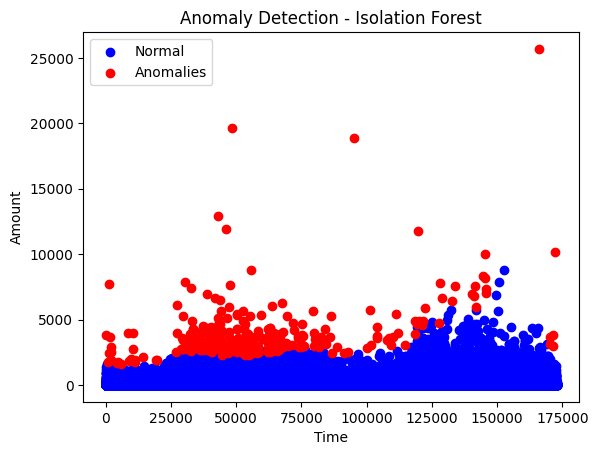

In [19]:
index = np.where(predictions < 0)[0]  # add [0]
normal_index = np.where(predictions == 1)[0]  # add [0]

plt.scatter(X.iloc[normal_index, 0], X.iloc[normal_index, 1], color='blue', label='Normal')
plt.scatter(X.iloc[index, 0], X.iloc[index, 1], color='red', label='Anomalies')

plt.xlabel('Time')
plt.ylabel('Amount')
plt.title('Anomaly Detection - Isolation Forest')
plt.legend()
plt.show()